# STAT3612 数据管线（合并版）

本 Notebook 将以下内容合并为一条可交互执行链路：

- `scripts/data_utils.py`：读 JSON / CSV、按 `case_id` 合并、`image_path` 修正
- `scripts/build_table.py`：统一大表 + 数据审计打印
- `scripts/baseline.py`：结构化 + radiomics 的 Logistic Regression baseline + 提交文件
- `docs/data_quality_report.md`：数据质量报告提纲（见下文 Markdown 区，运行后把打印结果填回 `docs/` 亦可）

**运行目录**：从仓库根目录启动 Jupyter，或从 `notebooks/` 启动均可；下方首个代码格会自动 `chdir` 到含 `kaggle-dataset` 的那一层。

**依赖**：`pip install pandas numpy scikit-learn jupyter`

---

## 文档：Data Quality Report 提纲（对应 `docs/data_quality_report.md`）

### 1. 基本信息

- **train 样本数**：（运行「数据审计」后填写）
- **val 样本数**：
- **test 样本数**：
- **主键列**：`case_id`

### 2. 各 split 统一表信息

将下方「数据审计」单元格的 **stdout** 复制到团队 `docs/data_quality_report.md` 对应小节。

### 3. 关键字段质量摘要

- **Age / age**：缺失率、填补策略
- **Sex / sex**：类别、unknown/None 处理
- **Tumor Location**：Top-N、拼写统一
- **Radiomics**：异常值、常数列、是否标准化

### 4. ID 对齐

- JSON vs `clinical_information`
- JSON vs `original_raw_report`

### 5. 结论与风险

- 可用字段、泄漏风险、类别不平衡等

## 0. 环境与仓库根目录

将 `scripts` 加入 `sys.path`，并把 `data_utils.DATA_DIR` 指到 `.../kaggle-dataset`。

In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
ROOT = _here if (_here / "kaggle-dataset").is_dir() else _here.parent
if not (ROOT / "kaggle-dataset").is_dir():
    raise FileNotFoundError(f"未找到 kaggle-dataset，当前 ROOT={ROOT}")

os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts"))

import data_utils as du

du.DATA_DIR = str(ROOT / "kaggle-dataset")
print("ROOT =", ROOT)
print("DATA_DIR =", du.DATA_DIR)

ROOT = /Users/sunnie/Desktop/STAT3612-Amateur-Neuro-Team
DATA_DIR = /Users/sunnie/Desktop/STAT3612-Amateur-Neuro-Team/kaggle-dataset


## 1. 数据审计（`build_table` 逻辑）

对 `train` / `val` / `test` 调用 `merge_all_sources`，打印 shape、缺失率 Top20、`Overall_class` 分布（若有）。

In [2]:
from typing import List

import pandas as pd


def audit_split(split: str, top_missing: int = 20) -> pd.DataFrame:
    df = du.merge_all_sources(split)

    print(f"\n[{split}] 统一表信息")
    print("-" * 40)
    print("shape:", df.shape)
    print("case_id 行数:", len(df), "唯一个数:", df["case_id"].nunique())

    miss = df.isna().mean().sort_values(ascending=False).head(top_missing)
    print("\n缺失率最高的前若干列：")
    print(miss.to_string())

    if "Overall_class" in df.columns:
        print("\n标签分布 Overall_class：")
        print(df["Overall_class"].value_counts(dropna=False))

    return df


dfs = {}
for s in ["train", "val", "test"]:
    dfs[s] = audit_split(s)


[train] 统一表信息
----------------------------------------
shape: (1983, 50)
case_id 行数: 1983 唯一个数: 1983

缺失率最高的前若干列：
flag                                   0.986889
location                               0.852748
ax_t1c__age                            0.697932
ax_t1__sex                             0.697932
ax_t1c__sex                            0.697932
ax_t2__sex                             0.697932
ax_t2__age                             0.697932
ax_t1__age                             0.697932
ax_t2f__age                            0.697932
Age_y                                  0.697932
ax_t2f__sex                            0.697932
Sex_x                                  0.695915
Age_x                                  0.695915
ax_t2f__rad_glcm_JointEntropy          0.361069
ax_t2f__rad_firstorder_Mean            0.361069
ax_t2f__rad_firstorder_Entropy         0.361069
ax_t2f__rad_firstorder_90Percentile    0.361069
ax_t2f__rad_glcm_Contrast              0.361069
ax_t1c__rad_firstorde

## 2.（可选）抽查一条 `image_path` 与 `.npy` 形状

确认路径映射 `image_features/` → `image_features/image_features/` 在本机可用。

In [3]:
import numpy as np

sample = dfs["train"].iloc[0]
cid = sample["case_id"]
paths = sample.get("image_path", [])
if isinstance(paths, list) and len(paths) > 0:
    p0 = paths[0]
    arr = du.load_image_feature_vector(p0)
    print("case_id:", cid)
    print("image_path[0]:", p0)
    print("npy shape:", arr.shape, "dtype:", arr.dtype)
else:
    print("该样本无 image_path 列表，跳过")

case_id: 7
image_path[0]: image_features/7/ax_t1/image.npy
npy shape: (2048,) dtype: float32


## 3. Baseline 训练、验证与提交（`baseline.py` 逻辑）

使用结构化临床字段 + 全部 radiomics 列；验证集指标为 Accuracy 与 F1-macro；预测写入项目根下 `outputs/sample_submission_v1.csv`（相对于 `ROOT`）。

In [4]:
import baseline as bl

model = bl.train_and_eval()
out = ROOT / "outputs" / "sample_submission_v1.csv"
out.parent.mkdir(parents=True, exist_ok=True)
bl.predict_test_and_save(model, output_path=str(out))

[train] 使用特征列数: 25
[val] 使用特征列数: 25
数值特征列数: 20 类别特征列数: 5
开始训练 baseline 模型...
在 val 集上评估...
Val Accuracy = 0.6820
Val F1-macro = 0.5638
[test] 使用特征列数: 25
在 test 集上生成预测...
提交文件已保存到: /Users/sunnie/Desktop/STAT3612-Amateur-Neuro-Team/outputs/sample_submission_v1.csv


## 4. 说明

- 命令行仍可使用：`python scripts/build_table.py`、`python scripts/baseline.py`，与 Notebook 共用同一套 `scripts/`。
- 若希望 **完全脱离** `scripts/`（单文件复制粘贴给朋友），可把 `data_utils.py` / `baseline.py` 全文贴进新代码格并去掉 `import baseline` — 当前设计优先避免三处重复维护。

## 5. EDA 初版（可直接用于 proposal 图表）

下面是可直接运行的 EDA 基础模块，建议按顺序执行。

- 标签分布与类别不平衡
- 缺失值概览
- 临床结构化字段（年龄、性别、肿瘤位置）
- 文本长度分析（`report` 与 `raw_report`）
- Radiomics 的相关性与快速单变量筛选

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# 统一取 train/val/test
train_df = dfs["train"].copy()
val_df = dfs["val"].copy()
test_df = dfs["test"].copy()

print("train/val/test shape:", train_df.shape, val_df.shape, test_df.shape)

train/val/test shape: (1983, 50) (283, 50) (572, 49)


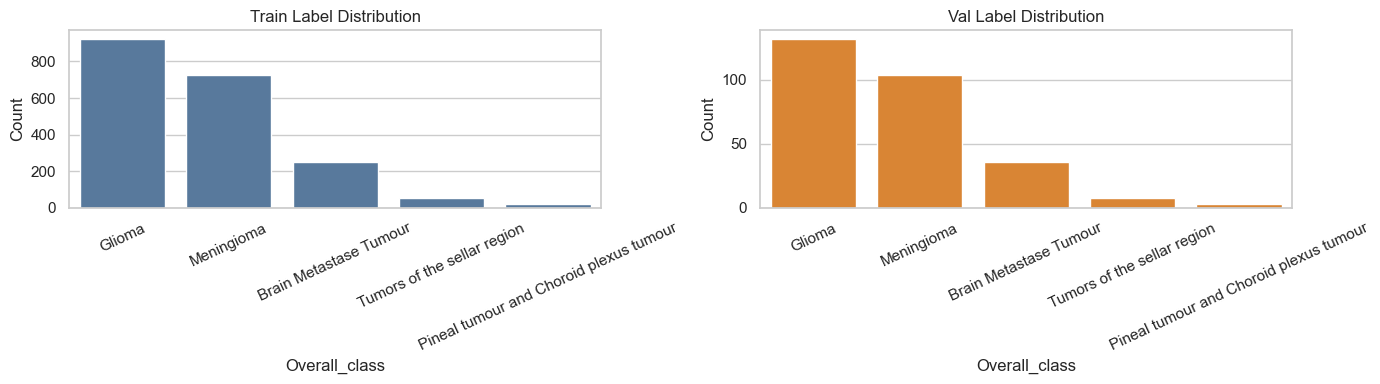

Train class ratio:
 Overall_class
Glioma                                     0.4660
Meningioma                                 0.3671
Brain Metastase Tumour                     0.1271
Tumors of the sellar region                0.0282
Pineal tumour and Choroid plexus tumour    0.0116
Name: count, dtype: float64

Val class ratio:
 Overall_class
Glioma                                     0.4664
Meningioma                                 0.3675
Brain Metastase Tumour                     0.1272
Tumors of the sellar region                0.0283
Pineal tumour and Choroid plexus tumour    0.0106
Name: count, dtype: float64


In [6]:
# 5.1 标签分布（train + val）
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train_counts = train_df["Overall_class"].value_counts()
val_counts = val_df["Overall_class"].value_counts()

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], color="#4C78A8")
axes[0].set_title("Train Label Distribution")
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylabel("Count")

sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[1], color="#F58518")
axes[1].set_title("Val Label Distribution")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Train class ratio:\n", (train_counts / train_counts.sum()).round(4))
print("\nVal class ratio:\n", (val_counts / val_counts.sum()).round(4))

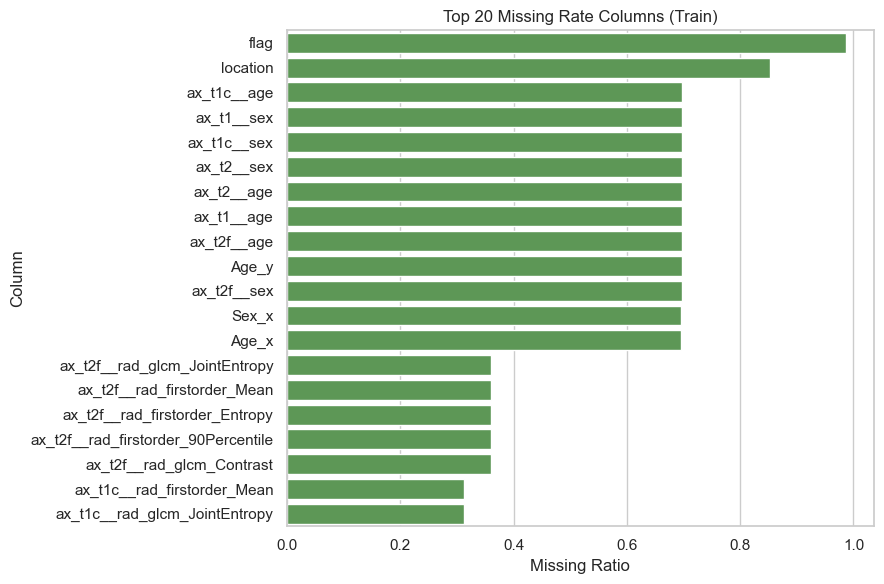

,missing_ratio
flag,0.986889
location,0.852748
ax_t1c__age,0.697932
ax_t1__sex,0.697932
ax_t1c__sex,0.697932
ax_t2__sex,0.697932
ax_t2__age,0.697932
ax_t1__age,0.697932
ax_t2f__age,0.697932
Age_y,0.697932


In [7]:
# 5.2 缺失值概览（train）
missing_rate = train_df.isna().mean().sort_values(ascending=False)
missing_top = missing_rate.head(20)

plt.figure(figsize=(9, 6))
sns.barplot(x=missing_top.values, y=missing_top.index, color="#54A24B")
plt.title("Top 20 Missing Rate Columns (Train)")
plt.xlabel("Missing Ratio")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

missing_summary = missing_rate.to_frame("missing_ratio")
missing_summary.head(10)

age_col: Age_x | sex_col: Sex_x | location_col: Tumor Location


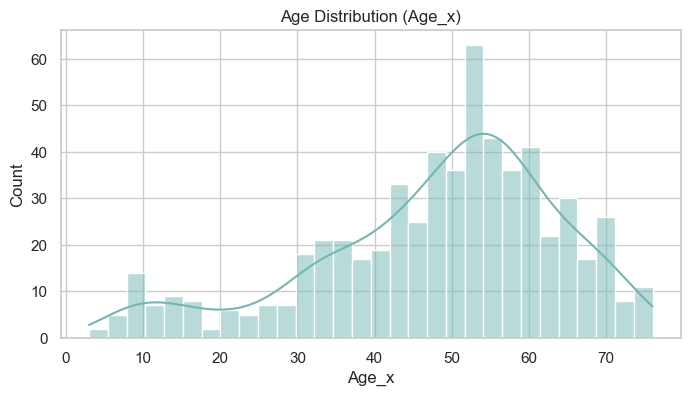

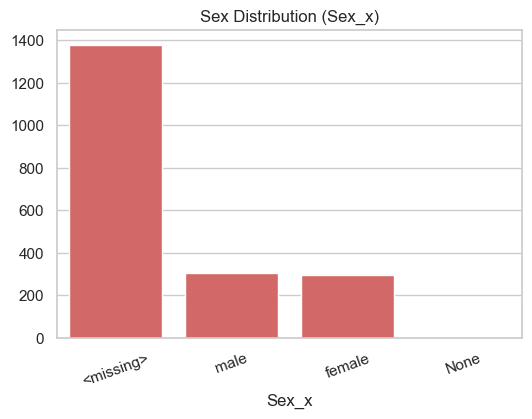

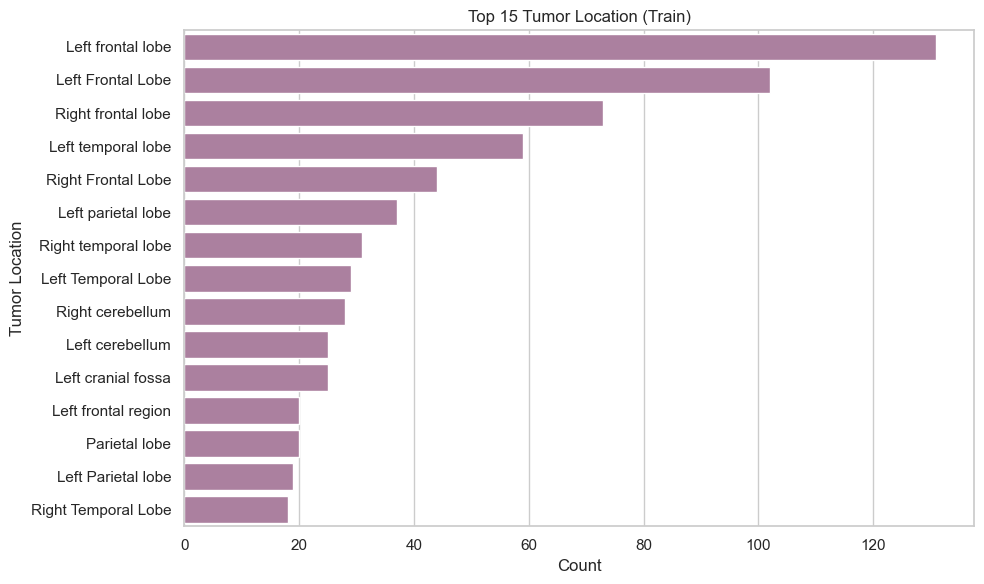

In [8]:
# 5.3 临床字段 EDA（年龄、性别、肿瘤位置）
# 年龄列可能存在 Age_x / Age_y / age，优先选择最常用版本
age_candidates = [c for c in ["Age_x", "Age_y", "Age", "age"] if c in train_df.columns]
age_col = age_candidates[0] if age_candidates else None

sex_candidates = [c for c in ["Sex_x", "Sex_y", "Sex", "sex"] if c in train_df.columns]
sex_col = sex_candidates[0] if sex_candidates else None

loc_col = "Tumor Location" if "Tumor Location" in train_df.columns else None

print("age_col:", age_col, "| sex_col:", sex_col, "| location_col:", loc_col)

if age_col:
    age_num = pd.to_numeric(train_df[age_col], errors="coerce")
    plt.figure(figsize=(8, 4))
    sns.histplot(age_num.dropna(), bins=30, kde=True, color="#72B7B2")
    plt.title(f"Age Distribution ({age_col})")
    plt.show()

if sex_col:
    plt.figure(figsize=(6, 4))
    sex_counts = train_df[sex_col].fillna("<missing>").astype(str).value_counts().head(10)
    sns.barplot(x=sex_counts.index, y=sex_counts.values, color="#E45756")
    plt.title(f"Sex Distribution ({sex_col})")
    plt.xticks(rotation=20)
    plt.show()

if loc_col:
    top_loc = train_df[loc_col].fillna("<missing>").astype(str).value_counts().head(15)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_loc.values, y=top_loc.index, color="#B279A2")
    plt.title("Top 15 Tumor Location (Train)")
    plt.xlabel("Count")
    plt.ylabel("Tumor Location")
    plt.tight_layout()
    plt.show()

text columns: ['report', 'raw_report']


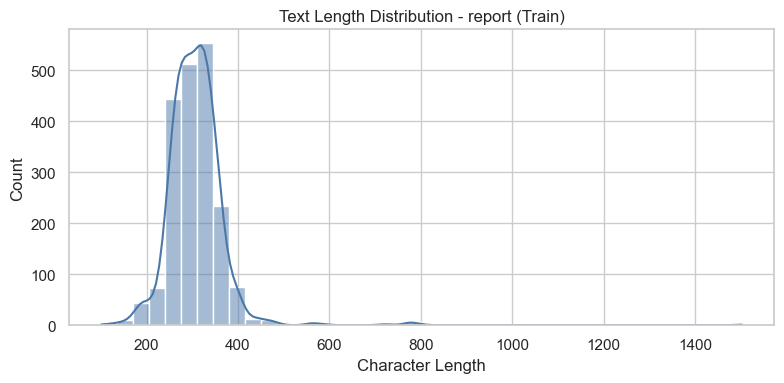

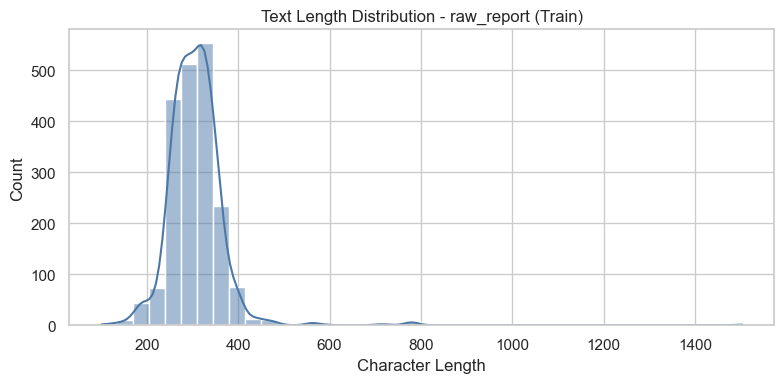

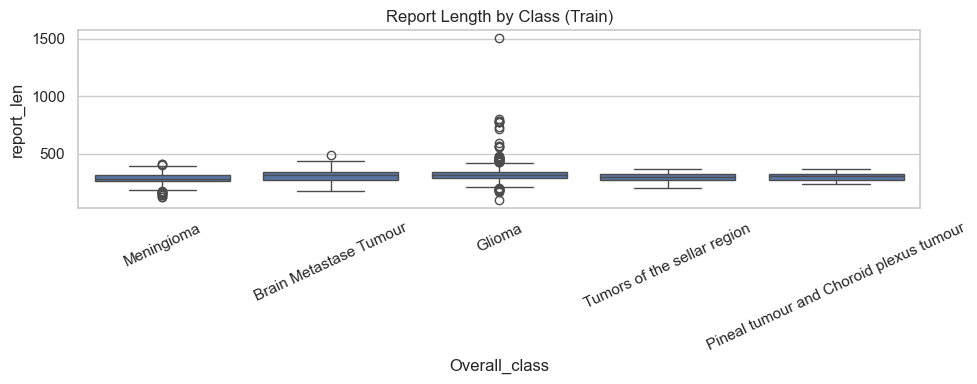

In [9]:
# 5.4 文本字段长度分析（report / raw_report）
text_candidates = [c for c in ["report", "raw_report"] if c in train_df.columns]
print("text columns:", text_candidates)

for tcol in text_candidates:
    text_len = train_df[tcol].fillna("").astype(str).str.len()
    plt.figure(figsize=(8, 4))
    sns.histplot(text_len, bins=40, kde=True, color="#4C78A8")
    plt.title(f"Text Length Distribution - {tcol} (Train)")
    plt.xlabel("Character Length")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# 按类别看 report 长度（若 report 存在）
if "report" in train_df.columns:
    tmp = train_df[["Overall_class", "report"]].copy()
    tmp["report_len"] = tmp["report"].fillna("").astype(str).str.len()
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=tmp, x="Overall_class", y="report_len")
    plt.xticks(rotation=25)
    plt.title("Report Length by Class (Train)")
    plt.tight_layout()
    plt.show()

Radiomics columns: 20


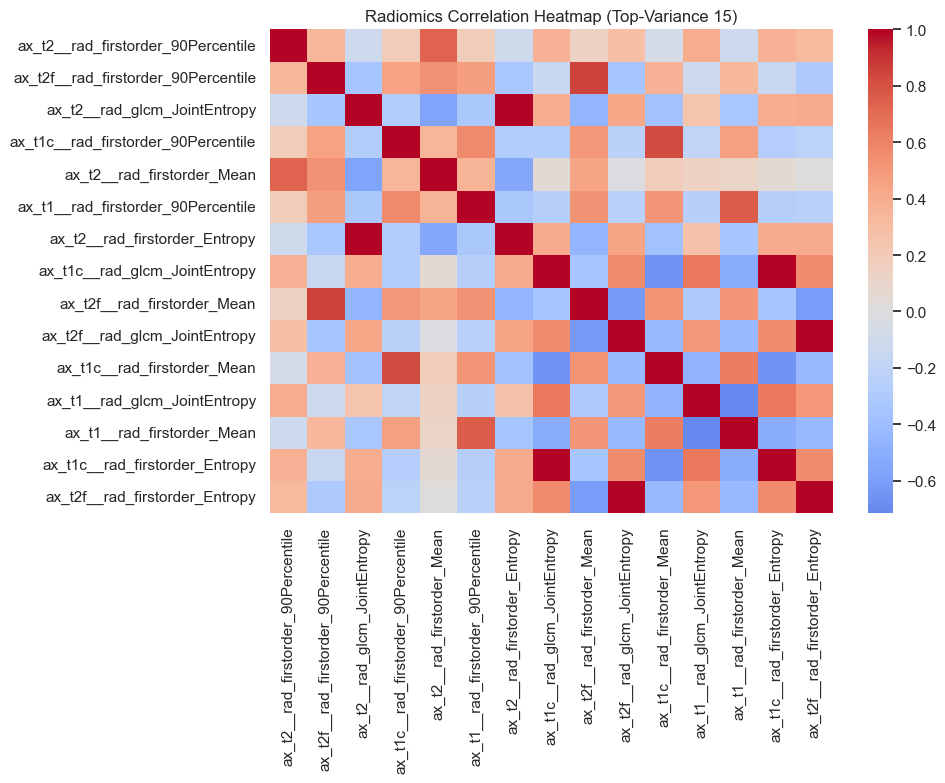

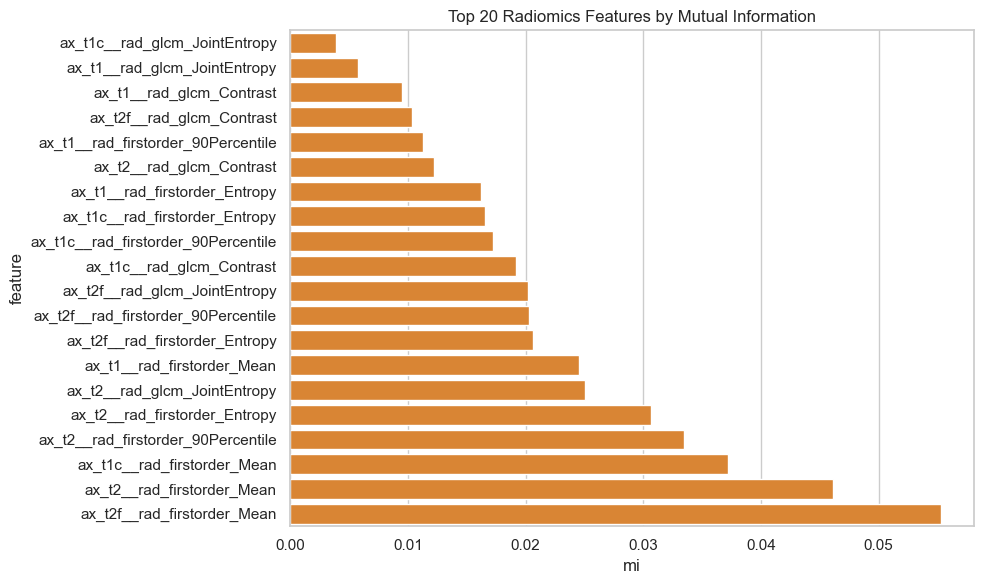

,feature,mi
15,ax_t2f__rad_firstorder_Mean,0.055333
10,ax_t2__rad_firstorder_Mean,0.046081
5,ax_t1c__rad_firstorder_Mean,0.037235
12,ax_t2__rad_firstorder_90Percentile,0.033476
11,ax_t2__rad_firstorder_Entropy,0.030638
14,ax_t2__rad_glcm_JointEntropy,0.025019
0,ax_t1__rad_firstorder_Mean,0.024579
16,ax_t2f__rad_firstorder_Entropy,0.020593
17,ax_t2f__rad_firstorder_90Percentile,0.020258
19,ax_t2f__rad_glcm_JointEntropy,0.020246


In [10]:
# 5.5 Radiomics 快速筛选：相关性 + MI 排名
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

rad_cols = [c for c in train_df.columns if "__rad_" in c or "rad_firstorder" in c or "rad_glcm" in c]
print("Radiomics columns:", len(rad_cols))

if len(rad_cols) > 0:
    X_rad = train_df[rad_cols].apply(pd.to_numeric, errors="coerce")
    y = train_df["Overall_class"].astype(str)

    # 相关性热图：挑方差最高的前15列，避免图太挤
    var_rank = X_rad.var(numeric_only=True).sort_values(ascending=False)
    top_corr_cols = var_rank.head(15).index.tolist()

    corr = X_rad[top_corr_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Radiomics Correlation Heatmap (Top-Variance 15)")
    plt.tight_layout()
    plt.show()

    # MI 排名（单变量）
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(X_rad)
    mi = mutual_info_classif(X_imp, y, random_state=42)
    mi_df = pd.DataFrame({"feature": rad_cols, "mi": mi}).sort_values("mi", ascending=False)

    plt.figure(figsize=(10, 6))
    top_mi = mi_df.head(20).iloc[::-1]
    sns.barplot(data=top_mi, x="mi", y="feature", color="#F58518")
    plt.title("Top 20 Radiomics Features by Mutual Information")
    plt.tight_layout()
    plt.show()

    display(mi_df.head(20))
else:
    print("未找到 radiomics 列，请检查 merge 逻辑。")

In [11]:
# 5.6 导出 EDA 关键表到 outputs/eda
eda_dir = ROOT / "outputs" / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

# 缺失率总表
missing_rate.to_csv(eda_dir / "train_missing_rate.csv", header=["missing_ratio"])

# 标签分布
train_df["Overall_class"].value_counts().to_csv(eda_dir / "train_label_distribution.csv", header=["count"])
val_df["Overall_class"].value_counts().to_csv(eda_dir / "val_label_distribution.csv", header=["count"])

# 文本长度（若存在）
if "report" in train_df.columns:
    report_len = train_df["report"].fillna("").astype(str).str.len()
    report_len.to_csv(eda_dir / "train_report_length.csv", index=False, header=["report_len"])

print("EDA tables saved to:", eda_dir)

EDA tables saved to: /Users/sunnie/Desktop/STAT3612-Amateur-Neuro-Team/outputs/eda


## 6. 你们下一步怎么分工接这个 EDA

- **A（数据质量）**：补充缺失值与异常值解释，完善 `docs/data_quality_report.md`
- **B（结构化）**：从 5.3 扩展到更多交叉图（按类别分层）
- **C（文本）**：在 5.4 基础上增加关键词统计、TF-IDF 初筛
- **D（radiomics）**：在 5.5 基础上做模态分开分析（t1/t1c/t2/t2f）
- **E（baseline）**：把 5.5 的 top 特征尝试接入 `scripts/baseline.py` 做对比实验

建议：每人改各自单元格，最终合并回这个 notebook。